In [85]:
import numpy as np
import torch
from pathlib import Path

# setup to allow reloading the plotting funcitons when necessary
import plotting_util
import importlib
importlib.reload(plotting_util)

from analysis.util import load_all_param_data

In [86]:
file = "../../data/unconstrained/rgd/metric_asymmetric__scaling_1.0__trial_0__geod_method_ivpbvp.pt"
data = torch.load(file, weights_only=False)

print(data)

RiemGradDescentResult(success=True, p=tensor([-0.3377, -0.0779,  0.1956]), iters=11, history=RiemGradDescentHistory(p_hist=tensor([[ 0.0213, -0.3656, -0.2538],
        [-0.0913, -0.2767, -0.1151],
        [-0.1696, -0.2145, -0.0180],
        [-0.2238, -0.1710,  0.0500],
        [-0.2614, -0.1406,  0.0976],
        [-0.2875, -0.1193,  0.1309],
        [-0.3057, -0.1044,  0.1542],
        [-0.3183, -0.0939,  0.1706],
        [-0.3272, -0.0866,  0.1820],
        [-0.3334, -0.0815,  0.1900],
        [-0.3377, -0.0779,  0.1956]]), f_hist=tensor([2.2136e-01, 1.0791e-01, 5.2216e-02, 2.5269e-02, 1.2257e-02, 5.9600e-03,
        2.9041e-03, 1.4173e-03, 6.9250e-04, 3.3864e-04, 1.6570e-04])))


In [87]:
constr_alg = "ralm"
sub_alg = "rgd"

constr_rgd_dir = Path(f"../../data/constrained/{constr_alg}_rgd/")
constr_rtr_dir = Path(f"../../data/constrained/{constr_alg}_rtr/")

constr_dirs = [constr_rgd_dir, constr_rtr_dir]
constr_data = load_all_param_data(constr_dirs)

constr_metric = "euclid"
constr_scaling = [0.5, 1.0, 1.5]
constr_methods = plotting_util._desired_method_order[1:] # no ivpbvp

save_dir = Path("ralm_figs/")

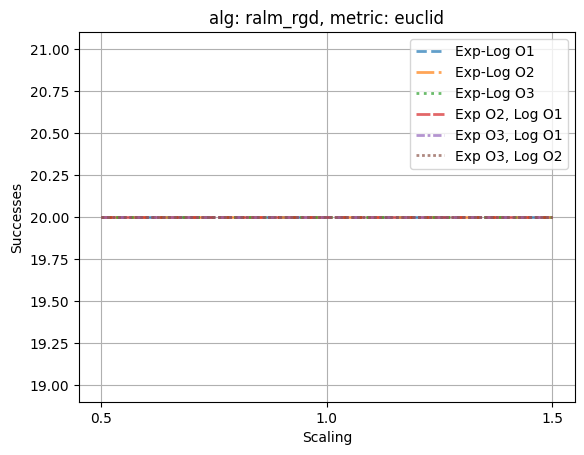

In [88]:
# generate the success vs scaling data
plotting_util.gen_success_vs_scaling_plots(constr_data, f"{constr_alg}_{sub_alg}", constr_metric, constr_scaling, constr_methods, show_titles=True, save_dir=save_dir)

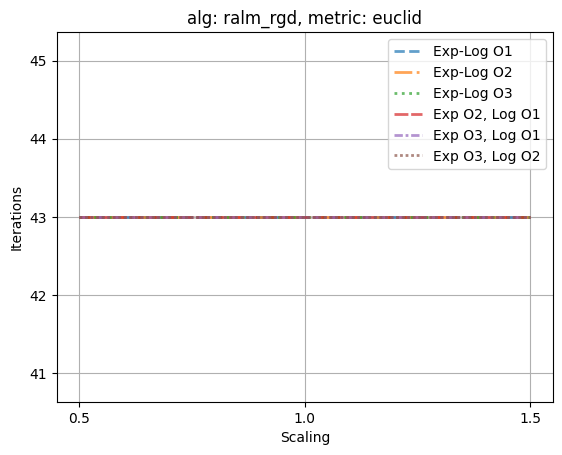

In [89]:
plotting_util.gen_iters_vs_scaling_plots(constr_data, f"{constr_alg}_{sub_alg}", constr_metric, constr_scaling, constr_methods, show_titles=True, save_dir=save_dir)

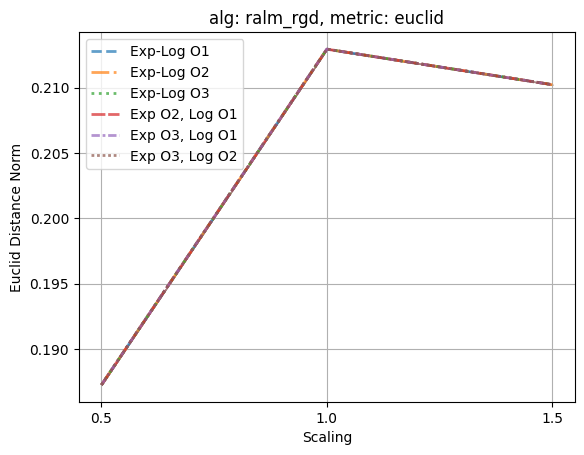

In [90]:
plotting_util.gen_euclid_nonoptimal_norms_vs_scaling_plots(constr_data, f"{constr_alg}_{sub_alg}", constr_metric, constr_scaling, constr_methods, target=plotting_util._constraint_target, use_log=False, show_titles=True, save_dir=save_dir)

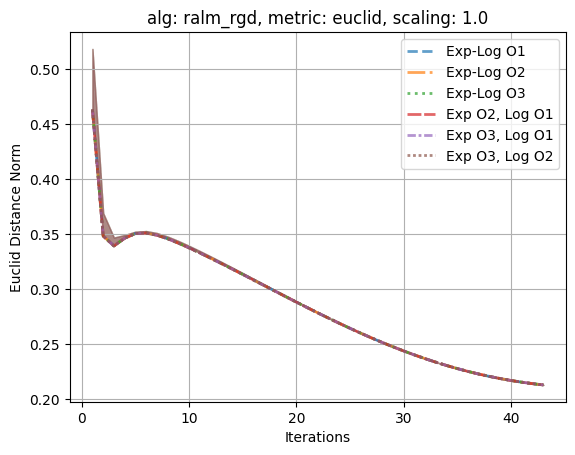

In [91]:
constr_scale = 1.0

plotting_util.gen_euclid_nonoptimal_norms_plots(constr_data, f"{constr_alg}_{sub_alg}", constr_metric, constr_scale, constr_methods, target=plotting_util._constraint_target, use_log=False, show_titles=True, save_dir=save_dir)

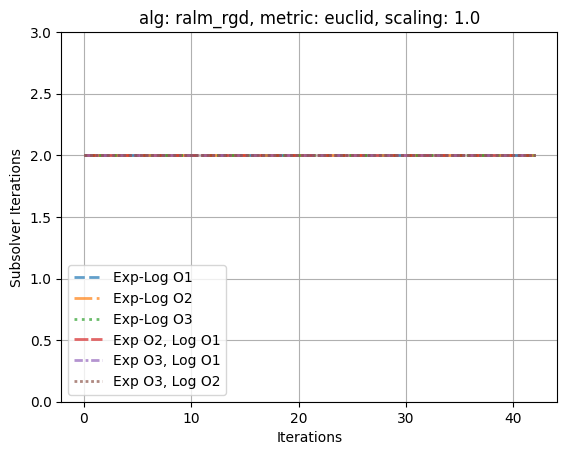

In [92]:
plotting_util.gen_subsolver_iters_plots(constr_data, f"{constr_alg}_{sub_alg}", constr_metric, constr_scale, constr_methods, show_titles=True, save_dir=save_dir)